# Курсовая работа: Имитационное моделирование СМО

## Постановка задачи

Вычислительная система (ВС) состоит из **3 серверов** с буфером на **3 программы**.

**Вариант 1 — линейный закон:**
- Интервал между приходами: равномерный на [Tzmin = 1/2, Tzmax = 5/6] сек
- Время обработки: равномерный на [Tsmin = 1, Tsmax = 5] сек

**Вариант 2 — экспоненциальный закон:**
- Интенсивность поступления: λ = 1.5 1/сек
- Среднее время обработки: tобр = 2 сек → μ = 0.5 1/сек

Если все серверы заняты → программа идёт в буфер (макс. 3).
Если буфер заполнен → программа покидает ВС необработанной.

**Состояния системы:**
| Состояние | Описание |
|-----------|----------|
| P0 | ВС не загружена |
| P1 | Загружен 1 сервер |
| P2 | Загружены 2 сервера |
| P3 | Загружены 3 сервера, буфер пуст |
| P4 | 3 сервера + 1 программа в буфере |
| P5 | 3 сервера + 2 программы в буфере |
| P6 | 3 сервера + 3 программы в буфере (система заполнена) |

In [1]:
import math
import numpy as np
import pandas as pd
import heapq
import matplotlib.pyplot as plt
from collections import deque

np.random.seed(42)

## Вспомогательные функции генерации случайных величин

In [2]:
def linear_time(t_min, t_max):
    """Линейный (равномерный) закон распределения."""
    return np.random.uniform(t_min, t_max)


def exponential_time(rate):
    """Экспоненциальный закон распределения."""
    return np.random.exponential(1.0 / rate)

## Имитационная модель СМО с буфером

Используется метод событийного моделирования (event-driven simulation).
Очередь событий реализована через min-heap (`heapq`).

**Типы событий:**
- `arrival` — приход новой программы
- `departure` — завершение обслуживания программы

In [3]:
def simulate_system(
    arrival_type="linear",
    service_type="linear",
    T=3600,
    n_servers=3,
    buffer_size=3,
    tz_min=1/2, tz_max=5/6,
    ts_min=1.0, ts_max=5.0,
    lmbda=1.5,
    mu=0.5
):
    """
    Имитационная модель СМО с n_servers серверами и буфером buffer_size.
    Возвращает словарь со всеми характеристиками ВС.
    """
    max_in_system = n_servers + buffer_size   # максимум программ в системе
    n_states = max_in_system + 1              # состояния 0..6

    current_time = 0.0
    last_event_time = 0.0
    busy_servers = 0
    buffer_count = 0

    events = []  # min-heap событий: (время, тип, данные)

    total_arrivals = 0
    total_served = 0
    total_rejected = 0

    state_time = np.zeros(n_states)   # время пребывания в каждом состоянии
    busy_servers_sum = 0.0            # для расчёта K
    buffer_sum = 0.0                  # для расчёта Nбуф

    total_wait_in_buffer = 0.0        # суммарное время ожидания в буфере
    total_passed_through_buffer = 0   # число программ, прошедших через буфер

    buffer_queue = deque()            # очередь: время прихода в буфер

    def gen_arrival():
        if arrival_type == "linear":
            return linear_time(tz_min, tz_max)
        else:
            return exponential_time(lmbda)

    def gen_service():
        if service_type == "linear":
            return linear_time(ts_min, ts_max)
        else:
            return exponential_time(mu)

    # Первый приход
    heapq.heappush(events, (gen_arrival(), "arrival", None))

    while events:
        current_time, event_type, event_data = heapq.heappop(events)

        if current_time > T:
            break

        # Обновляем статистику за интервал [last_event_time, current_time]
        dt = current_time - last_event_time
        state = busy_servers + buffer_count
        state_time[state] += dt
        busy_servers_sum += busy_servers * dt
        buffer_sum += buffer_count * dt
        last_event_time = current_time

        if event_type == "arrival":
            total_arrivals += 1
            heapq.heappush(events, (current_time + gen_arrival(), "arrival", None))

            if busy_servers < n_servers:
                # Есть свободный сервер — сразу обслуживаем
                busy_servers += 1
                svc = gen_service()
                # event_data = (время_прихода_в_систему, время_начала_обслуживания)
                heapq.heappush(events, (current_time + svc, "departure", (current_time, current_time)))
            elif buffer_count < buffer_size:
                # Серверы заняты, есть место в буфере
                buffer_count += 1
                buffer_queue.append(current_time)
            else:
                # Буфер заполнен — отказ
                total_rejected += 1

        elif event_type == "departure":
            arrival_in_system, service_start = event_data
            total_served += 1

            if buffer_count > 0:
                # Берём программу из буфера на освободившийся сервер
                buffer_count -= 1
                buf_arrival = buffer_queue.popleft()

                # Время ожидания в буфере = текущее время - время прихода в буфер
                wait = current_time - buf_arrival
                total_wait_in_buffer += wait
                total_passed_through_buffer += 1

                svc = gen_service()
                heapq.heappush(events, (current_time + svc, "departure", (buf_arrival, current_time)))
            else:
                busy_servers -= 1

    # ── Вычисление характеристик ──────────────────────────────────────────
    total_sim_time = np.sum(state_time)
    if total_sim_time == 0:
        total_sim_time = T

    P = state_time / total_sim_time

    Q     = total_served / total_arrivals if total_arrivals > 0 else 0.0
    A     = total_served / T
    P_rej = total_rejected / total_arrivals if total_arrivals > 0 else 0.0
    K     = busy_servers_sum / total_sim_time
    N_buf = buffer_sum / total_sim_time
    N_prog = sum(i * P[i] for i in range(n_states))
    T_prog = N_prog / A if A > 0 else 0.0
    T_buf  = (total_wait_in_buffer / total_passed_through_buffer
              if total_passed_through_buffer > 0 else 0.0)

    return {
        "P": P,
        "P0": P[0], "P1": P[1], "P2": P[2], "P3": P[3],
        "P4": P[4], "P5": P[5], "P6": P[6],
        "Q": Q, "A": A, "P_rej": P_rej, "K": K,
        "N_prog": N_prog, "T_prog": T_prog,
        "N_buf": N_buf, "T_buf": T_buf,
        "total_arrivals": total_arrivals,
        "total_served": total_served,
        "total_rejected": total_rejected,
    }

In [4]:
def run_experiments(n_runs=10, **kwargs):
    """Запускает n_runs симуляций и возвращает усреднённые результаты."""
    results = [simulate_system(**kwargs) for _ in range(n_runs)]
    avg = {}
    for key in results[0]:
        if key == "P":
            avg[key] = np.mean([r[key] for r in results], axis=0)
        else:
            avg[key] = np.mean([r[key] for r in results])
    return avg, results

## Теоретическая модель M/M/3/6

Для системы **M/M/c/K** (c серверов, K максимум в системе) вероятности состояний:

$$P_n = \begin{cases}
P_0 \cdot \dfrac{\rho^n}{n!}, & 0 \le n \le c \\[6pt]
P_0 \cdot \dfrac{\rho^n}{c! \cdot c^{n-c}}, & c < n \le K
\end{cases}$$

где $\rho = \lambda / \mu$, $c = 3$, $K = 6$, $P_0 = \left(\sum_{n=0}^{K} \text{числитель}_n\right)^{-1}$

In [ ]:
def theoretical_MMcK(lmbda, mu, c=3, K=6):
    """
    Теоретическая модель M/M/c/K.
    c — число серверов, K — максимальное число программ в системе.
    """
    rho = lmbda / mu

    unnorm = []
    for n in range(K + 1):
        if n <= c:
            unnorm.append(rho**n / math.factorial(n))
        else:
            unnorm.append(rho**n / (math.factorial(c) * c**(n - c)))

    denom = sum(unnorm)
    P = [u / denom for u in unnorm]

    P_rej  = P[K]
    Q      = 1 - P_rej
    A      = lmbda * Q
    K_avg  = sum(min(n, c) * P[n] for n in range(K + 1))
    N_buf  = sum((n - c) * P[n] for n in range(c + 1, K + 1))
    N_prog = sum(n * P[n] for n in range(K + 1))
    T_prog = N_prog / A if A > 0 else 0.0
    T_buf  = N_buf  / A if A > 0 else 0.0

    return {
        "P": P,
        "P0": P[0], "P1": P[1], "P2": P[2], "P3": P[3],
        "P4": P[4], "P5": P[5], "P6": P[6],
        "Q": Q, "A": A, "P_rej": P_rej, "K": K_avg,
        "N_prog": N_prog, "T_prog": T_prog,
        "N_buf": N_buf, "T_buf": T_buf,
    }


# Параметры экспоненциального варианта
lmbda_exp = 1.5
mu_exp    = 0.5   # 1 / tобр = 1/2

theory = theoretical_MMcK(lmbda=lmbda_exp, mu=mu_exp, c=3, K=6)

print(f"Теоретическая модель M/M/3/6:")
print(f"  ρ = λ/μ = {lmbda_exp/mu_exp:.2f}")
print(f"  P0     = {theory['P0']:.6f}")
print(f"  P_отк  = {theory['P_rej']:.6f}")
print(f"  Q      = {theory['Q']:.6f}")
print(f"  A      = {theory['A']:.6f} 1/сек")

Теоретическая модель M/M/3/6:
  ρ = λ/μ = 3.00
  P0     = 0.037736
  P_отк  = 0.169811
  Q      = 0.830189
  A      = 1.245283 1/сек


## Запуск имитационных моделей

In [6]:
np.random.seed(42)

print("Запуск: линейный закон (10 прогонов × 1 час)...")
linear_res, linear_all = run_experiments(
    n_runs=10,
    arrival_type="linear", service_type="linear",
    T=3600, n_servers=3, buffer_size=3,
    tz_min=1/2, tz_max=5/6,
    ts_min=1.0, ts_max=5.0
)
print(f"  Приходов: {linear_res['total_arrivals']:.0f} | "
      f"Обслужено: {linear_res['total_served']:.0f} | "
      f"Отказов: {linear_res['total_rejected']:.0f}")

print("\nЗапуск: экспоненциальный закон (10 прогонов × 1 час)...")
exp_res, exp_all = run_experiments(
    n_runs=10,
    arrival_type="exponential", service_type="exponential",
    T=3600, n_servers=3, buffer_size=3,
    lmbda=1.5, mu=0.5
)
print(f"  Приходов: {exp_res['total_arrivals']:.0f} | "
      f"Обслужено: {exp_res['total_served']:.0f} | "
      f"Отказов: {exp_res['total_rejected']:.0f}")

Запуск: линейный закон (10 прогонов × 1 час)...
  Приходов: 5399 | Обслужено: 3598 | Отказов: 1796

Запуск: экспоненциальный закон (10 прогонов × 1 час)...
  Приходов: 5378 | Обслужено: 4473 | Отказов: 900


In [7]:
# Список характеристик (ключ, описание)
chars = [
    ("P0",     "P0 — ВС не загружена"),
    ("P1",     "P1 — загружен 1 сервер"),
    ("P2",     "P2 — загружены 2 сервера"),
    ("P3",     "P3 — загружены 3 сервера"),
    ("P4",     "P4 — в буфере 1 программа"),
    ("P5",     "P5 — в буфере 2 программы"),
    ("P6",     "P6 — в буфере 3 программы"),
    ("Q",      "Q — относит. пропускная способность"),
    ("A",      "A — абсолют. пропускная способность (1/сек)"),
    ("P_rej",  "Pотк — вероятность отказа"),
    ("K",      "K — среднее число занятых серверов"),
    ("N_prog", "Nпрог — среднее число программ в ВС"),
    ("T_prog", "Tпрог — среднее время в ВС (сек)"),
    ("N_buf",  "Nбуф — среднее число программ в буфере"),
    ("T_buf",  "Tбуф — среднее время ожидания в буфере (сек)"),
]

pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_colwidth", 55)

## Таблица 1: Характеристики ВС — линейный закон

Параметры: Tzmin = 1/2 сек, Tzmax = 5/6 сек, Tsmin = 1 сек, Tsmax = 5 сек
Средняя интенсивность поступления: λ = 1/(Tz_mean) ≈ 1.5 1/сек
Среднее время обслуживания: ts_mean = 3 сек → μ = 1/3 1/сек
Нагрузка на систему: ρ = λ/μ = 4.5 (высокая нагрузка)

In [8]:
df1 = pd.DataFrame({
    "Характеристика": [c[1] for c in chars],
    "Значение":       [linear_res[c[0]] for c in chars],
})
df1

,Характеристика,Значение
0,P0 — ВС не загружена,0.000193
1,P1 — загружен 1 сервер,0.000187
2,P2 — загружены 2 сервера,0.000408
3,P3 — загружены 3 сервера,0.005837
4,P4 — в буфере 1 программа,0.089069
5,P5 — в буфере 2 программы,0.370024
6,P6 — в буфере 3 программы,0.534283
7,Q — относит. пропускная способность,0.666281
8,A — абсолют. пропускная способность (1/сек),0.999306
9,Pотк — вероятность отказа,0.332664


## Таблица 2: Экспоненциальный закон — имитация vs теория M/M/3/6

Параметры: λ = 1.5 1/сек, μ = 0.5 1/сек, ρ = λ/μ = 3.0

In [9]:
df2 = pd.DataFrame({
    "Характеристика":  [c[1] for c in chars],
    "Имитация (эксп)": [exp_res[c[0]] for c in chars],
    "Теория M/M/3/6":  [theory[c[0]]  for c in chars],
})
df2

,Характеристика,Имитация (эксп),Теория M/M/3/6
0,P0 — ВС не загружена,0.037742,0.037736
1,P1 — загружен 1 сервер,0.114785,0.113208
2,P2 — загружены 2 сервера,0.171803,0.169811
3,P3 — загружены 3 сервера,0.171454,0.169811
4,P4 — в буфере 1 программа,0.168907,0.169811
5,P5 — в буфере 2 программы,0.168180,0.169811
6,P6 — в буфере 3 программы,0.167129,0.169811
7,Q — относит. пропускная способность,0.831808,0.830189
8,A — абсолют. пропускная способность (1/сек),1.242556,1.245283
9,Pотк — вероятность отказа,0.167430,0.169811


## Таблица 3: Сравнение линейного и экспоненциального законов

In [10]:
df3 = pd.DataFrame({
    "Характеристика":         [c[1] for c in chars],
    "Линейный закон":         [linear_res[c[0]] for c in chars],
    "Экспоненциальный закон": [exp_res[c[0]]    for c in chars],
})
df3

,Характеристика,Линейный закон,Экспоненциальный закон
0,P0 — ВС не загружена,0.000193,0.037742
1,P1 — загружен 1 сервер,0.000187,0.114785
2,P2 — загружены 2 сервера,0.000408,0.171803
3,P3 — загружены 3 сервера,0.005837,0.171454
4,P4 — в буфере 1 программа,0.089069,0.168907
5,P5 — в буфере 2 программы,0.370024,0.168180
6,P6 — в буфере 3 программы,0.534283,0.167129
7,Q — относит. пропускная способность,0.666281,0.831808
8,A — абсолют. пропускная способность (1/сек),0.999306,1.242556
9,Pотк — вероятность отказа,0.332664,0.167430


## Графики вероятностей состояний

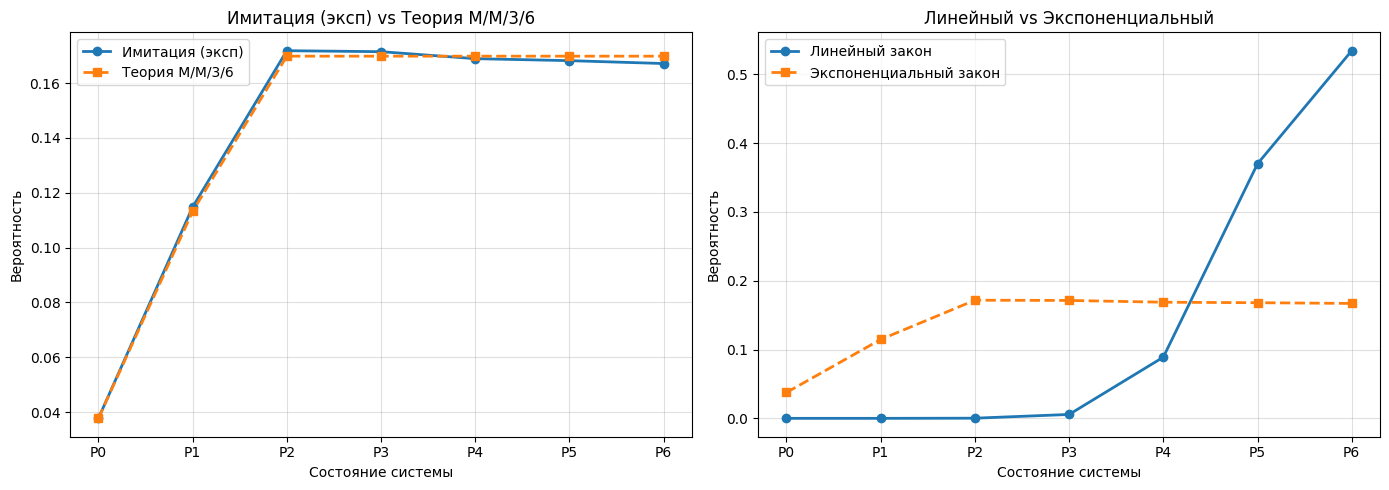

In [11]:
states = np.arange(7)
labels = [f"P{i}" for i in range(7)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Имитация (эксп) vs Теория M/M/3/6
ax = axes[0]
ax.plot(states, exp_res["P"], marker='o', linewidth=2, label="Имитация (эксп)")
ax.plot(states, theory["P"], marker='s', linestyle='--', linewidth=2, label="Теория M/M/3/6")
ax.set_xticks(states)
ax.set_xticklabels(labels)
ax.set_xlabel("Состояние системы")
ax.set_ylabel("Вероятность")
ax.set_title("Имитация (эксп) vs Теория M/M/3/6")
ax.legend()
ax.grid(True, alpha=0.4)

# График 2: Линейный vs Экспоненциальный
ax = axes[1]
ax.plot(states, linear_res["P"], marker='o', linewidth=2, label="Линейный закон")
ax.plot(states, exp_res["P"],    marker='s', linestyle='--', linewidth=2, label="Экспоненциальный закон")
ax.set_xticks(states)
ax.set_xticklabels(labels)
ax.set_xlabel("Состояние системы")
ax.set_ylabel("Вероятность")
ax.set_title("Линейный vs Экспоненциальный")
ax.legend()
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

## Столбчатая диаграмма: сравнение ключевых характеристик

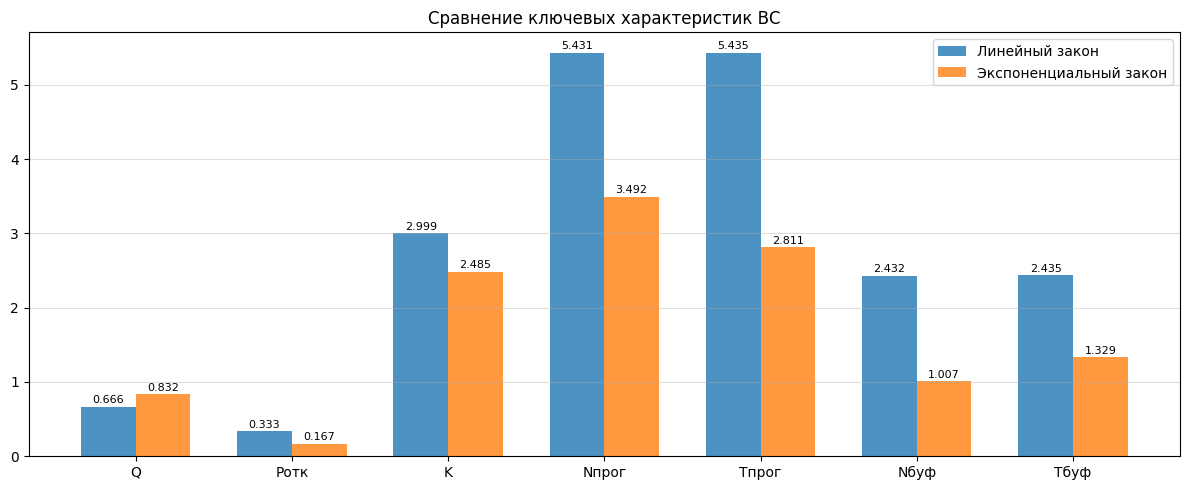

In [12]:
key_metrics = ["Q", "P_rej", "K", "N_prog", "T_prog", "N_buf", "T_buf"]
metric_labels = ["Q", "Pотк", "K", "Nпрог", "Tпрог", "Nбуф", "Tбуф"]

lin_vals = [linear_res[k] for k in key_metrics]
exp_vals = [exp_res[k]    for k in key_metrics]

x = np.arange(len(key_metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width/2, lin_vals, width, label="Линейный закон", alpha=0.8)
bars2 = ax.bar(x + width/2, exp_vals, width, label="Экспоненциальный закон", alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_title("Сравнение ключевых характеристик ВС")
ax.legend()
ax.grid(True, axis='y', alpha=0.4)

# Подписи значений
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## Выводы

### Линейный закон (Tzmin=1/2, Tzmax=5/6, Tsmin=1, Tsmax=5)
- Средняя интенсивность поступления λ ≈ 1.5 1/сек, среднее время обслуживания 3 сек → ρ = 4.5
- Система работает в условиях **высокой нагрузки**: P6 ≈ 0.53 (буфер заполнен более половины времени)
- Вероятность отказа Pотк ≈ 0.33 — каждая третья программа не обслуживается
- Все 3 сервера заняты практически всё время (K ≈ 3.0)

### Экспоненциальный закон (λ=1.5, μ=0.5, ρ=3.0)
- Нагрузка ρ = 3.0 — система работает в **умеренном режиме**
- Вероятность отказа Pотк ≈ 0.17 — значительно ниже, чем в линейном случае
- Имитационная модель хорошо согласуется с теоретической моделью M/M/3/6

### Сравнение законов
- При одинаковой средней интенсивности поступления (λ ≈ 1.5) линейный закон даёт **худшие** характеристики
- Это объясняется тем, что при линейном законе среднее время обслуживания (3 сек) больше, чем при экспоненциальном (2 сек)
- Экспоненциальный закон обеспечивает более высокую пропускную способность Q ≈ 0.83 vs 0.67